# Module A: Accelerometer

### A.1 Static Noise Test

In [30]:
import csv
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

A1_FILE = Path("4_13_26") / "A1.StaticNoise.csv"
A2_FILE = Path("4_13_26") / "A2.GravityVectorCheck.csv"
B1_FILE = Path("4_13_26") / "B1.ZeroRateBiasTest.csv"
B2_FILE = Path("4_13_26") / "B2.KnownRotationTest.csv"

FS_DEFAULT = 10.0
G = 9.80665
ACC_NOISE_DENSITY_UG_SQRT_HZ = 120.0
A2_FACE_LABELS = ["+X", "-X", "+Y", "-Y", "+Z", "-Z"]
B2_GYRZ_TURN_THRESHOLD_DPS = 20.0
GYR_NOISE_DENSITY_DPS_SQRT_HZ = 0.015

def _to_float(x):
    try:
        s = str(x).strip()
        if s == "":
            return np.nan
        return float(s)
    except:
        return np.nan

def load_csv_dict(filename):
    with open(filename, "r", newline="", encoding="utf-8-sig") as f:
        reader = csv.DictReader(f)
        rows = list(reader)
    if not rows:
        raise ValueError(f"No rows found in {filename}")
    data = {}
    headers = [h.strip() for h in reader.fieldnames]
    for h in headers:
        data[h] = [row.get(h, "") for row in rows]
    return data

def get_time_vector(data_dict, n, fs_default=FS_DEFAULT):
    if "Timestamp" in data_dict:
        ts = np.array([_to_float(x) for x in data_dict["Timestamp"]], dtype=float)
        if np.isfinite(ts).sum() >= 2:
            t = ts - ts[0]
            dt = np.diff(t)
            dt = dt[np.isfinite(dt)]
            dt = dt[dt > 0]
            if len(dt) > 0:
                return t
    return np.arange(n) / fs_default

def get_col(data_dict, name):
    if name not in data_dict:
        raise KeyError(f"Column '{name}' not found. Found: {list(data_dict.keys())}")
    return np.array([_to_float(x) for x in data_dict[name]], dtype=float)

def sample_rate_from_t(t, fs_default=FS_DEFAULT):
    dt = np.diff(t)
    dt = dt[np.isfinite(dt)]
    dt = dt[dt > 0]
    if len(dt) == 0:
        return fs_default
    return 1.0 / np.median(dt)


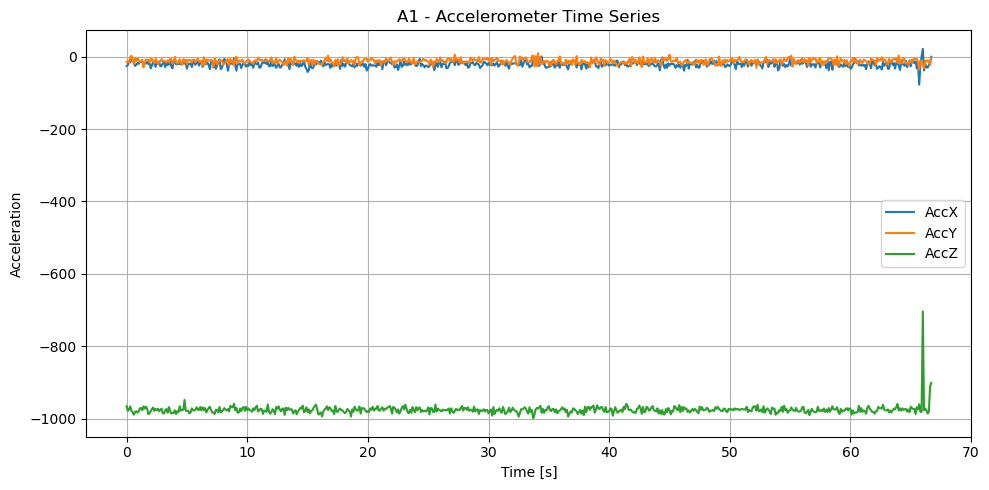

Sample rate [Hz]: 10.000
Means:
  AccX: -21.088323
  AccY: -12.656931
  AccZ: -975.139536
Measured noise RMS:
  AccX: 7.495380
  AccY: 6.630583
  AccZ: 12.911749
Predicted datasheet RMS (approx): 2.631400e-03


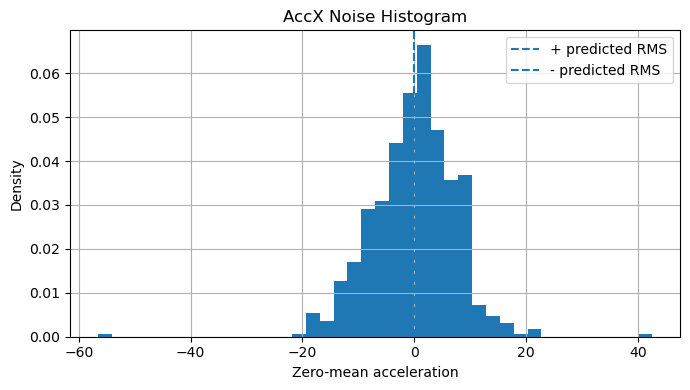

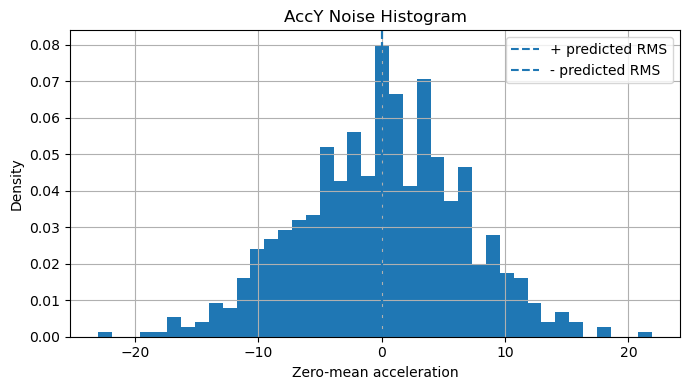

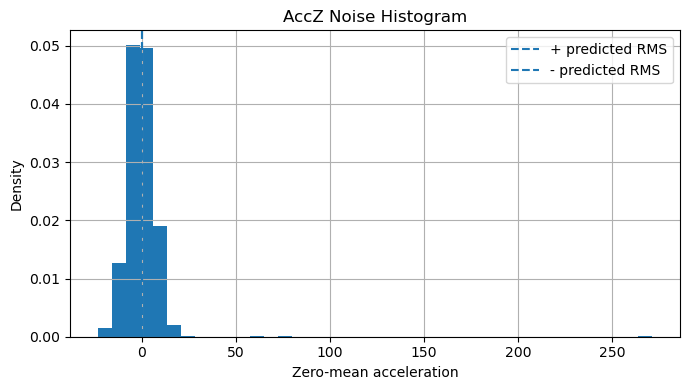

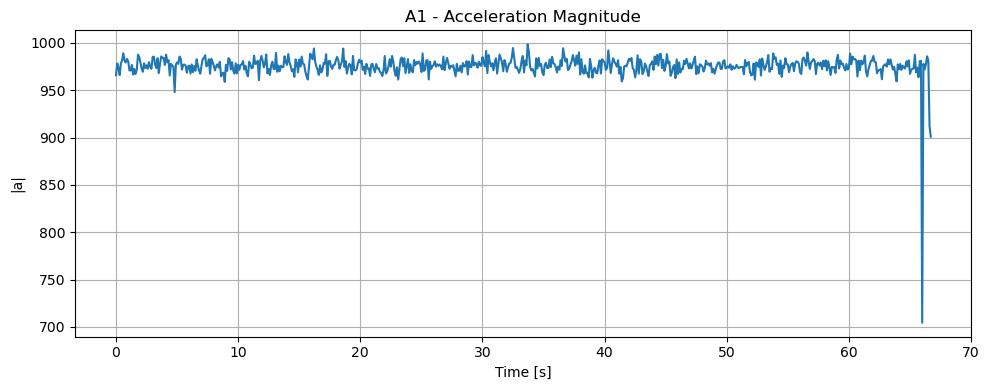

In [31]:
data_A1 = load_csv_dict(A1_FILE)
n_A1 = len(next(iter(data_A1.values())))
t_A1 = get_time_vector(data_A1, n_A1)
fs_A1 = sample_rate_from_t(t_A1)

ax = get_col(data_A1, "AccX")
ay = get_col(data_A1, "AccY")
az = get_col(data_A1, "AccZ")

plt.figure(figsize=(10, 5))
plt.plot(t_A1, ax, label="AccX")
plt.plot(t_A1, ay, label="AccY")
plt.plot(t_A1, az, label="AccZ")
plt.xlabel("Time [s]")
plt.ylabel("Acceleration")
plt.title("A1 - Accelerometer Time Series")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

means_A1 = {
    "AccX": np.nanmean(ax),
    "AccY": np.nanmean(ay),
    "AccZ": np.nanmean(az),
}
rms_meas_A1 = {
    "AccX": np.sqrt(np.nanmean((ax - np.nanmean(ax))**2)),
    "AccY": np.sqrt(np.nanmean((ay - np.nanmean(ay))**2)),
    "AccZ": np.sqrt(np.nanmean((az - np.nanmean(az))**2)),
}

acc_nd_si = ACC_NOISE_DENSITY_UG_SQRT_HZ * 1e-6 * G
rms_pred_A1 = acc_nd_si * np.sqrt(fs_A1 / 2.0)

print(f"Sample rate [Hz]: {fs_A1:.3f}")
print("Means:")
for k, v in means_A1.items():
    print(f"  {k}: {v:.6f}")
print("Measured noise RMS:")
for k, v in rms_meas_A1.items():
    print(f"  {k}: {v:.6f}")
print(f"Predicted datasheet RMS (approx): {rms_pred_A1:.6e}")

for label, y in [("AccX", ax), ("AccY", ay), ("AccZ", az)]:
    plt.figure(figsize=(7, 4))
    plt.hist(y - np.nanmean(y), bins=40, density=True)
    plt.axvline(rms_pred_A1, linestyle="--", label="+ predicted RMS")
    plt.axvline(-rms_pred_A1, linestyle="--", label="- predicted RMS")
    plt.title(f"{label} Noise Histogram")
    plt.xlabel("Zero-mean acceleration")
    plt.ylabel("Density")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

amag_A1 = np.sqrt(ax**2 + ay**2 + az**2)
plt.figure(figsize=(10, 4))
plt.plot(t_A1, amag_A1)
plt.xlabel("Time [s]")
plt.ylabel("|a|")
plt.title("A1 - Acceleration Magnitude")
plt.grid(True)
plt.tight_layout()
plt.show()


### A.2 Gravity Vector Check

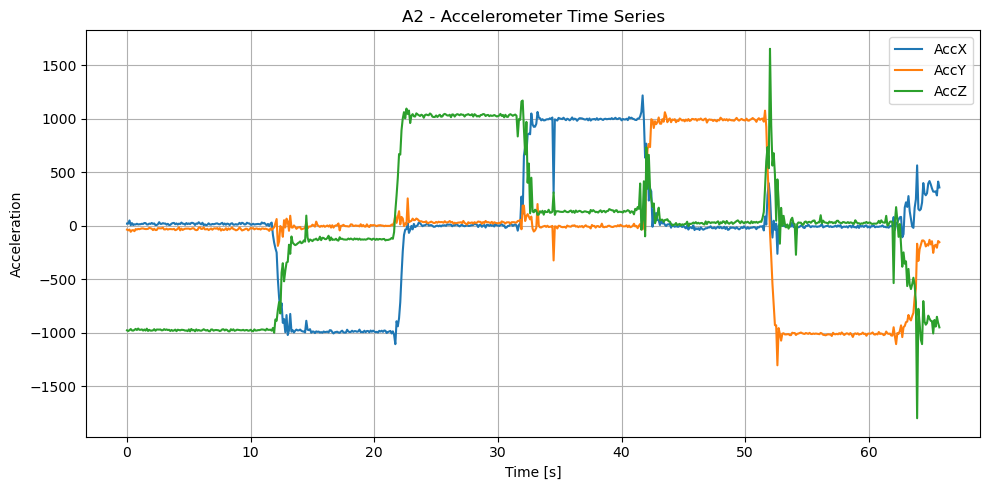

Segment means:
Face      AccX        AccY        AccZ
+X     17.493119  -30.972018  -974.026972
-X    -858.532294   -5.488440  -257.422936
+Y      8.569174   40.952752  986.996055
-Y    867.528073  126.388532  149.185872
+Z     -6.105688  540.832385   88.343211
-Z     63.226018  -852.776814  -194.940708
Bias X, scale X: -420.519587, 44.664866
Bias Y, scale Y: 83.670642, -4.356012
Bias Z, scale Z: -53.298748, 14.443460


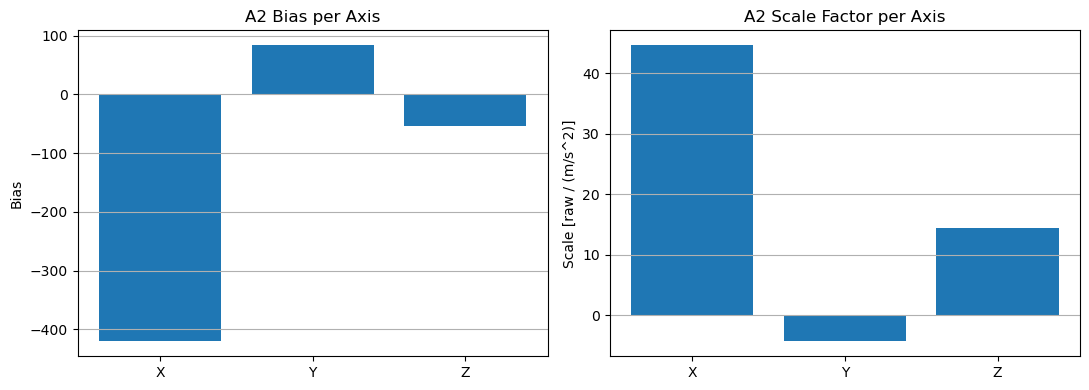

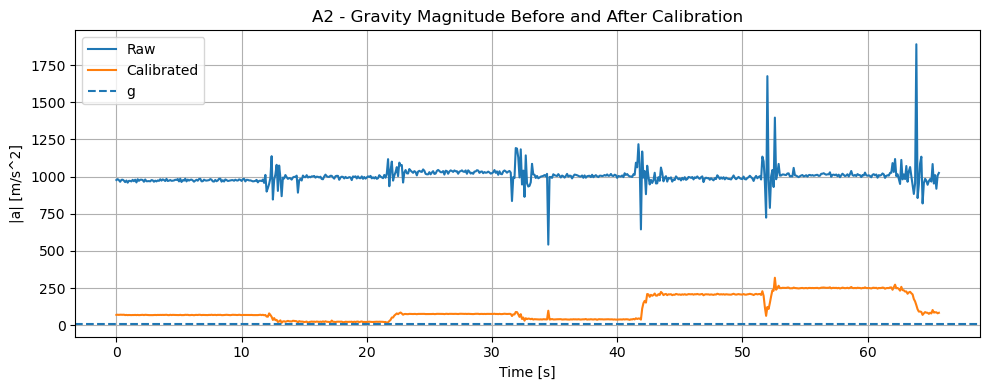

In [32]:

data_A2 = load_csv_dict(A2_FILE)
n_A2 = len(next(iter(data_A2.values())))
t_A2 = get_time_vector(data_A2, n_A2)

ax2 = get_col(data_A2, "AccX")
ay2 = get_col(data_A2, "AccY")
az2 = get_col(data_A2, "AccZ")

plt.figure(figsize=(10, 5))
plt.plot(t_A2, ax2, label="AccX")
plt.plot(t_A2, ay2, label="AccY")
plt.plot(t_A2, az2, label="AccZ")
plt.xlabel("Time [s]")
plt.ylabel("Acceleration")
plt.title("A2 - Accelerometer Time Series")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

n = len(ax2)
seg_len = n // 6
if seg_len < 5:
    raise ValueError("A2 file is too short to split into 6 face segments.")

seg_means = []
for i in range(6):
    i0 = i * seg_len
    i1 = (i + 1) * seg_len if i < 5 else n
    mx = np.nanmean(ax2[i0:i1])
    my = np.nanmean(ay2[i0:i1])
    mz = np.nanmean(az2[i0:i1])
    seg_means.append((A2_FACE_LABELS[i], mx, my, mz))

print("Segment means:")
print("Face      AccX        AccY        AccZ")
for row in seg_means:
    print(f"{row[0]:<4}  {row[1]:>10.6f}  {row[2]:>10.6f}  {row[3]:>10.6f}")

bx = 0.5 * (seg_means[0][1] + seg_means[1][1])
sx = 0.5 * (seg_means[0][1] - seg_means[1][1]) / G
by = 0.5 * (seg_means[2][2] + seg_means[3][2])
sy = 0.5 * (seg_means[2][2] - seg_means[3][2]) / G
bz = 0.5 * (seg_means[4][3] + seg_means[5][3])
sz = 0.5 * (seg_means[4][3] - seg_means[5][3]) / G

print(f"Bias X, scale X: {bx:.6f}, {sx:.6f}")
print(f"Bias Y, scale Y: {by:.6f}, {sy:.6f}")
print(f"Bias Z, scale Z: {bz:.6f}, {sz:.6f}")

ax2_cal = (ax2 - bx) / sx
ay2_cal = (ay2 - by) / sy
az2_cal = (az2 - bz) / sz

amag_raw_A2 = np.sqrt(ax2**2 + ay2**2 + az2**2)
amag_cal_A2 = np.sqrt(ax2_cal**2 + ay2_cal**2 + az2_cal**2)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(["X", "Y", "Z"], [bx, by, bz])
axes[0].set_title("A2 Bias per Axis")
axes[0].set_ylabel("Bias")
axes[0].grid(True, axis="y")

axes[1].bar(["X", "Y", "Z"], [sx, sy, sz])
axes[1].set_title("A2 Scale Factor per Axis")
axes[1].set_ylabel("Scale [raw / (m/s^2)]")
axes[1].grid(True, axis="y")

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(t_A2, amag_raw_A2, label="Raw")
plt.plot(t_A2, amag_cal_A2, label="Calibrated")
plt.axhline(G, linestyle="--", label="g")
plt.xlabel("Time [s]")
plt.ylabel("|a| [m/s^2]")
plt.title("A2 - Gravity Magnitude Before and After Calibration")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# Module B: Gyroscope

### B.1 Zero-Rate Bias Test

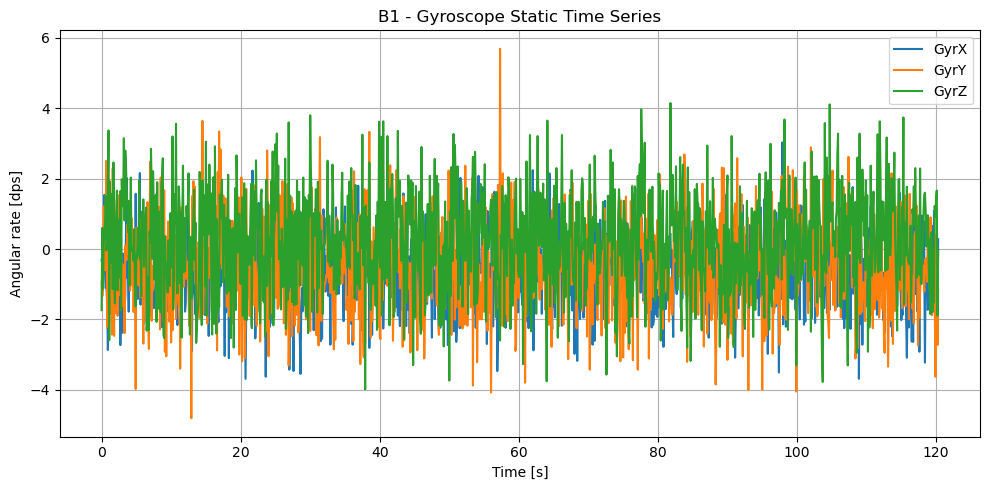

ZRO bias [dps]:
  GyrX: -0.646827 dps   (38.810 deg/min)
  GyrY: -0.441204 dps   (26.472 deg/min)
  GyrZ: 0.252334 dps   (15.140 deg/min)
Integrated drift over record [deg]:
  Raw X, Y, Z: -77.876, -53.018, 30.470
  Corr X, Y, Z: -0.062, 0.059, 0.114


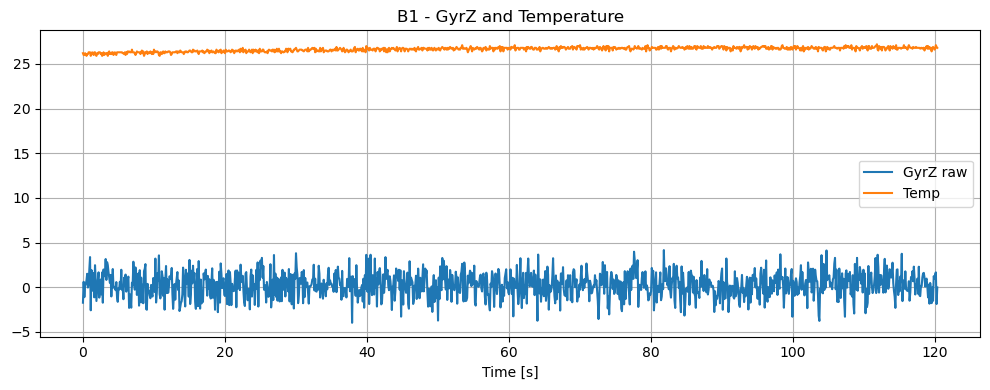

Corr(Temp, GyrZ): -0.0029
d(GyrZ)/dTemp: -0.017050 dps/degC
Predicted gyro RMS from noise density [dps]: 0.033541


In [33]:

data_B1 = load_csv_dict(B1_FILE)
n_B1 = len(next(iter(data_B1.values())))
t_B1 = get_time_vector(data_B1, n_B1)
fs_B1 = sample_rate_from_t(t_B1)
dt_B1 = 1.0 / fs_B1

gx = get_col(data_B1, "GyrX")
gy = get_col(data_B1, "GyrY")
gz = get_col(data_B1, "GyrZ")
temp = np.array([_to_float(x) for x in data_B1["Temp"]], dtype=float) if "Temp" in data_B1 else None

plt.figure(figsize=(10, 5))
plt.plot(t_B1, gx, label="GyrX")
plt.plot(t_B1, gy, label="GyrY")
plt.plot(t_B1, gz, label="GyrZ")
plt.xlabel("Time [s]")
plt.ylabel("Angular rate [dps]")
plt.title("B1 - Gyroscope Static Time Series")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

bias_B1 = {
    "GyrX": np.nanmean(gx),
    "GyrY": np.nanmean(gy),
    "GyrZ": np.nanmean(gz),
}
drift_deg_min_B1 = {k: 60.0 * abs(v) for k, v in bias_B1.items()}

print("ZRO bias [dps]:")
for k, v in bias_B1.items():
    print(f"  {k}: {v:.6f} dps   ({drift_deg_min_B1[k]:.3f} deg/min)")

gx_corr = gx - bias_B1["GyrX"]
gy_corr = gy - bias_B1["GyrY"]
gz_corr = gz - bias_B1["GyrZ"]

ang_x_raw = np.zeros_like(gx, dtype=float)
ang_y_raw = np.zeros_like(gy, dtype=float)
ang_z_raw = np.zeros_like(gz, dtype=float)
ang_x_cor = np.zeros_like(gx, dtype=float)
ang_y_cor = np.zeros_like(gy, dtype=float)
ang_z_cor = np.zeros_like(gz, dtype=float)

for i in range(1, len(gx)):
    ang_x_raw[i] = ang_x_raw[i-1] + 0.5 * (gx[i-1] + gx[i]) * dt_B1
    ang_y_raw[i] = ang_y_raw[i-1] + 0.5 * (gy[i-1] + gy[i]) * dt_B1
    ang_z_raw[i] = ang_z_raw[i-1] + 0.5 * (gz[i-1] + gz[i]) * dt_B1
    ang_x_cor[i] = ang_x_cor[i-1] + 0.5 * (gx_corr[i-1] + gx_corr[i]) * dt_B1
    ang_y_cor[i] = ang_y_cor[i-1] + 0.5 * (gy_corr[i-1] + gy_corr[i]) * dt_B1
    ang_z_cor[i] = ang_z_cor[i-1] + 0.5 * (gz_corr[i-1] + gz_corr[i]) * dt_B1

print("Integrated drift over record [deg]:")
print(f"  Raw X, Y, Z: {ang_x_raw[-1]:.3f}, {ang_y_raw[-1]:.3f}, {ang_z_raw[-1]:.3f}")
print(f"  Corr X, Y, Z: {ang_x_cor[-1]:.3f}, {ang_y_cor[-1]:.3f}, {ang_z_cor[-1]:.3f}")

if temp is not None:
    plt.figure(figsize=(10, 4))
    plt.plot(t_B1, gz, label="GyrZ raw")
    plt.plot(t_B1, temp, label="Temp")
    plt.xlabel("Time [s]")
    plt.title("B1 - GyrZ and Temperature")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    mask = np.isfinite(temp) & np.isfinite(gz)
    if np.sum(mask) >= 2:
        corr_temp_gz = np.corrcoef(temp[mask], gz[mask])[0, 1]
        slope_gz_temp = np.polyfit(temp[mask], gz[mask], 1)[0]
        print(f"Corr(Temp, GyrZ): {corr_temp_gz:.4f}")
        print(f"d(GyrZ)/dTemp: {slope_gz_temp:.6f} dps/degC")

gyr_rms_pred_B1 = GYR_NOISE_DENSITY_DPS_SQRT_HZ * np.sqrt(fs_B1 / 2.0)
print(f"Predicted gyro RMS from noise density [dps]: {gyr_rms_pred_B1:.6f}")


### B.2 Known Rotation Test

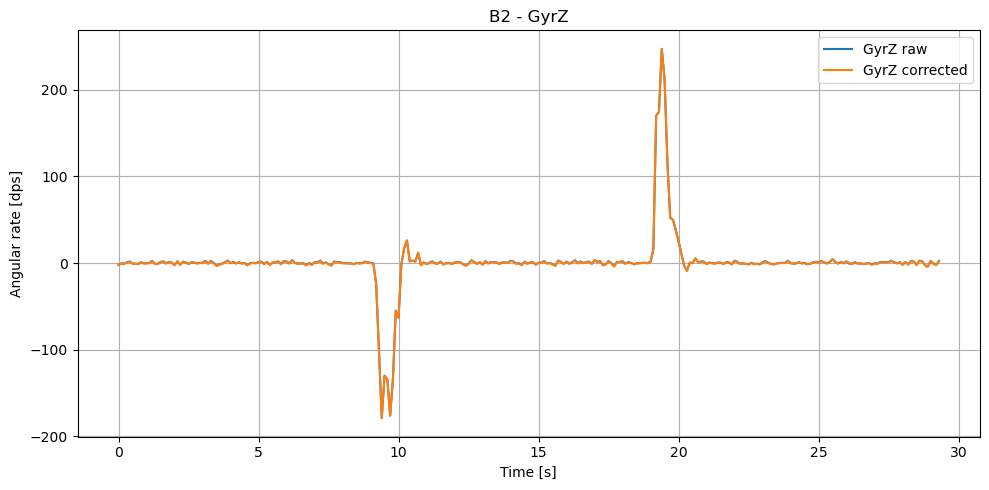

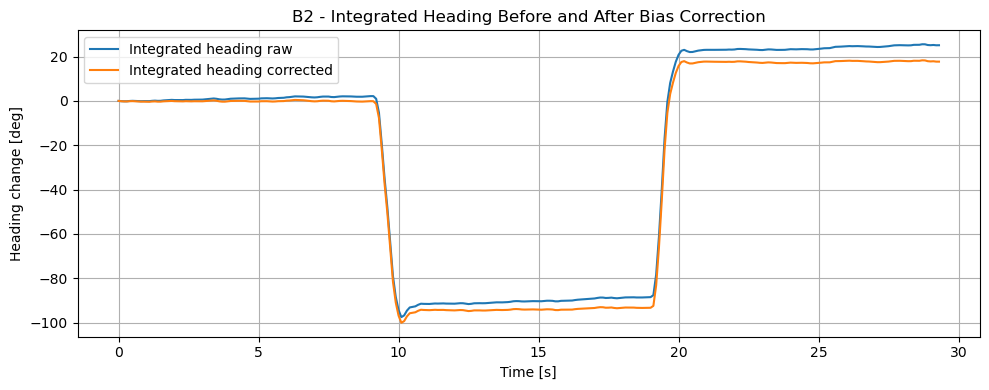

Detected turn segments (row indices): [(92, 100), (103, 103), (192, 200)]

segment    i0    i1      t0[s]      t1[s]   angle_raw   angle_corr   err_raw   err_corr
   1      92   100      9.200     10.000     -95.240      -95.442     5.240     5.442
   2     103   103     10.300     10.300       0.000        0.000    90.000    90.000
   3     192   200     19.200     20.000      99.069       98.868     9.069     8.868


In [34]:

data_B2 = load_csv_dict(B2_FILE)
n_B2 = len(next(iter(data_B2.values())))
t_B2 = get_time_vector(data_B2, n_B2)
fs_B2 = sample_rate_from_t(t_B2)
dt_B2 = 1.0 / fs_B2

gz_B2 = get_col(data_B2, "GyrZ")
z_bias_from_B1 = bias_B1["GyrZ"] if "bias_B1" in globals() else 0.0
gz_B2_corr = gz_B2 - z_bias_from_B1

heading_raw_B2 = np.zeros_like(gz_B2, dtype=float)
heading_cor_B2 = np.zeros_like(gz_B2, dtype=float)
for i in range(1, len(gz_B2)):
    heading_raw_B2[i] = heading_raw_B2[i-1] + 0.5 * (gz_B2[i-1] + gz_B2[i]) * dt_B2
    heading_cor_B2[i] = heading_cor_B2[i-1] + 0.5 * (gz_B2_corr[i-1] + gz_B2_corr[i]) * dt_B2

plt.figure(figsize=(10, 5))
plt.plot(t_B2, gz_B2, label="GyrZ raw")
plt.plot(t_B2, gz_B2_corr, label="GyrZ corrected")
plt.xlabel("Time [s]")
plt.ylabel("Angular rate [dps]")
plt.title("B2 - GyrZ")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(t_B2, heading_raw_B2, label="Integrated heading raw")
plt.plot(t_B2, heading_cor_B2, label="Integrated heading corrected")
plt.xlabel("Time [s]")
plt.ylabel("Heading change [deg]")
plt.title("B2 - Integrated Heading Before and After Bias Correction")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

moving = np.abs(gz_B2) > B2_GYRZ_TURN_THRESHOLD_DPS

segments = []
in_seg = False
start = None
for i, m in enumerate(moving):
    if m and not in_seg:
        start = i
        in_seg = True
    elif (not m) and in_seg:
        segments.append((start, i - 1))
        in_seg = False
if in_seg:
    segments.append((start, len(moving) - 1))

print("Detected turn segments (row indices):", segments)
print()
print("segment    i0    i1      t0[s]      t1[s]   angle_raw   angle_corr   err_raw   err_corr")
for k, (i0, i1) in enumerate(segments, start=1):
    angle_raw = np.sum((gz_B2[i0:i1] + gz_B2[i0+1:i1+1]) * 0.5 * dt_B2)
    angle_cor = np.sum((gz_B2_corr[i0:i1] + gz_B2_corr[i0+1:i1+1]) * 0.5 * dt_B2)
    err_raw = abs(abs(angle_raw) - 90.0)
    err_cor = abs(abs(angle_cor) - 90.0)
    print(f"{k:>4}   {i0:>5} {i1:>5}  {t_B2[i0]:>9.3f}  {t_B2[i1]:>9.3f}  {angle_raw:>10.3f}  {angle_cor:>11.3f}  {err_raw:>8.3f}  {err_cor:>8.3f}")


# Module C: Magnetometer

### C.1 Raw Data Collection

In [35]:
import csv
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.gridspec import GridSpec


path = '4_13_26\C2.HardSoftIron.csv'

rows = []
with open(path, newline='') as f:
    reader = csv.DictReader(f)
    for row in reader:
        rows.append({k: float(v) if k not in ('Timestamp', 'Sensor') else v
                     for k, v in row.items()})

print(f'Loaded {len(rows)} samples')

mx = [r['MagX'] for r in rows]
my = [r['MagY'] for r in rows]
mz = [r['MagZ'] for r in rows]
t  = list(range(len(rows)))

Loaded 617 samples


#### 1. Plot the raw data 

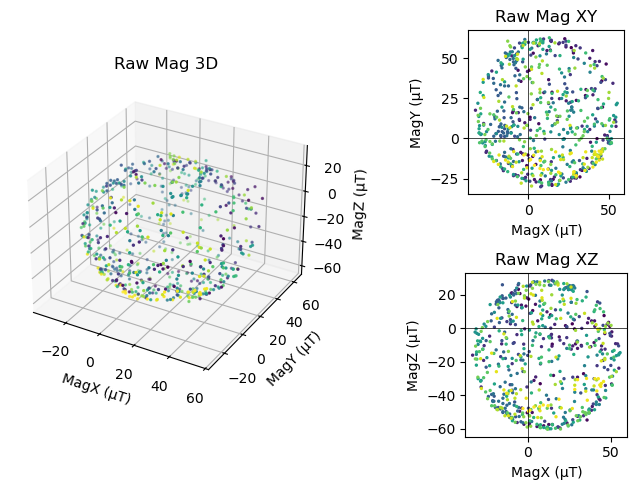

In [36]:
fig = plt.figure(figsize=(8, 5))  # slightly wider overall
gs = GridSpec(2, 2, width_ratios=[1, 1.5])  # RIGHT side wider

# --- Left: 3D plot ---
ax3d = fig.add_subplot(gs[:, 0], projection='3d')
ax3d.scatter(mx, my, mz, s=2, c=t, cmap='viridis')
ax3d.set_title('Raw Mag 3D')
ax3d.set_xlabel('MagX (µT)')
ax3d.set_ylabel('MagY (µT)')
ax3d.set_zlabel('MagZ (µT)')

# --- Top-right: XY ---
ax_xy = fig.add_subplot(gs[0, 1])
ax_xy.scatter(mx, my, s=2, c=t, cmap='viridis')
ax_xy.set_aspect('equal')
ax_xy.set_title('Raw Mag XY')
ax_xy.set_xlabel('MagX (µT)')
ax_xy.set_ylabel('MagY (µT)')
ax_xy.axhline(0, color='k', lw=0.5)
ax_xy.axvline(0, color='k', lw=0.5)

# --- Bottom-right: XZ ---
ax_xz = fig.add_subplot(gs[1, 1])
ax_xz.scatter(mx, mz, s=2, c=t, cmap='viridis')
ax_xz.set_aspect('equal')
ax_xz.set_title('Raw Mag XZ')
ax_xz.set_xlabel('MagX (µT)')
ax_xz.set_ylabel('MagZ (µT)')
ax_xz.axhline(0, color='k', lw=0.5)
ax_xz.axvline(0, color='k', lw=0.5)

plt.tight_layout()
plt.show()

### C.2 Hard/Soft Iron Calibration

In [37]:
mx_min = min(mx)
mx_max = max(mx)
my_min = min(my)
my_max = max(my)
mz_min = min(mz)
mz_max = max(mz)

offset_x = (mx_max + mx_min) / 2
offset_y = (my_max + my_min) / 2
offset_z = (mz_max + mz_min) / 2

print(f'MagX range: {mx_min:.2f} to {mx_max:.2f} µT')
print(f'MagY range: {my_min:.2f} to {my_max:.2f} µT')
print(f'MagZ range: {mz_min:.2f} to {mz_max:.2f} µT')
print(f'Hard iron offsets: X={offset_x:.3f}, Y={offset_y:.3f}, Z={offset_z:.3f} µT')

MagX range: -33.00 to 55.35 µT
MagY range: -30.15 to 62.70 µT
MagZ range: -60.45 to 28.80 µT
Hard iron offsets: X=11.175, Y=16.275, Z=-15.825 µT


#### Calibrate with the Hard Offsets solved for and plot it:

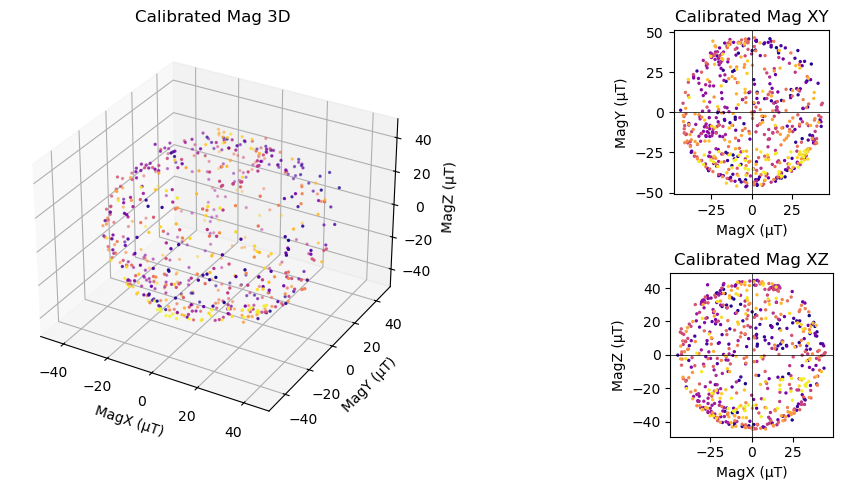

In [38]:
mx_cal = [x - offset_x for x in mx]
my_cal = [y - offset_y for y in my]
mz_cal = [z - offset_z for z in mz]

# --- Figure layout ---
fig = plt.figure(figsize=(12, 5))
gs = GridSpec(2, 2, width_ratios=[1, 1.5])  # right side wider

# --- Left: 3D plot ---
ax3d = fig.add_subplot(gs[:, 0], projection='3d')
ax3d.scatter(mx_cal, my_cal, mz_cal, s=2, c=t, cmap='plasma')
ax3d.set_title('Calibrated Mag 3D')
ax3d.set_xlabel('MagX (µT)')
ax3d.set_ylabel('MagY (µT)')
ax3d.set_zlabel('MagZ (µT)')

# --- Top-right: XY ---
ax_xy = fig.add_subplot(gs[0, 1])
ax_xy.scatter(mx_cal, my_cal, s=2, c=t, cmap='plasma')
ax_xy.set_aspect('equal')
ax_xy.set_title('Calibrated Mag XY')
ax_xy.set_xlabel('MagX (µT)')
ax_xy.set_ylabel('MagY (µT)')
ax_xy.axhline(0, color='k', lw=0.5)
ax_xy.axvline(0, color='k', lw=0.5)

# --- Bottom-right: XZ ---
ax_xz = fig.add_subplot(gs[1, 1])
ax_xz.scatter(mx_cal, mz_cal, s=2, c=t, cmap='plasma')
ax_xz.set_aspect('equal')
ax_xz.set_title('Calibrated Mag XZ')
ax_xz.set_xlabel('MagX (µT)')
ax_xz.set_ylabel('MagZ (µT)')
ax_xz.axhline(0, color='k', lw=0.5)
ax_xz.axvline(0, color='k', lw=0.5)

plt.tight_layout()
plt.show()

### C.3 Field Magnitude Histogram

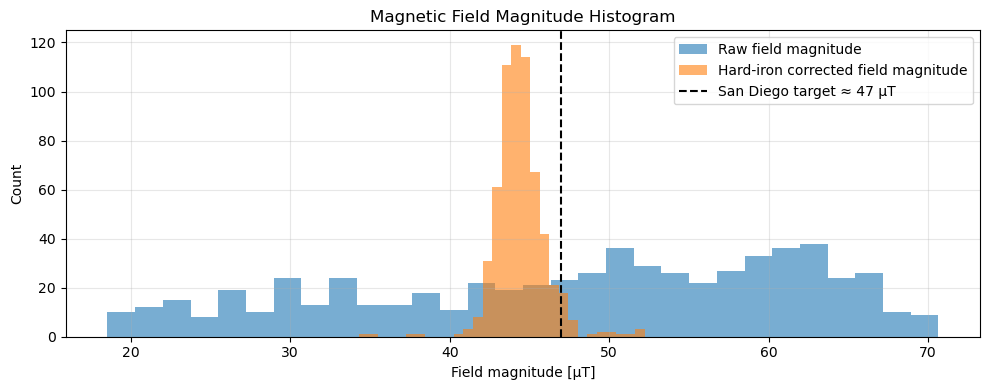

Raw magnitude mean: 47.82 µT
Corrected magnitude mean: 44.41 µT
Raw magnitude std: 13.65 µT
Corrected magnitude std: 1.61 µT
Target local field: ~47.0 µT


In [48]:
# Field-magnitude histogram (raw vs. hard-iron corrected)
mag_raw = np.sqrt(np.array(mx)**2 + np.array(my)**2 + np.array(mz)**2)
mag_cal = np.sqrt(np.array(mx_cal)**2 + np.array(my_cal)**2 + np.array(mz_cal)**2)

target_field_uT = 47.0

plt.figure(figsize=(10, 4))
plt.hist(mag_raw, bins=30, alpha=0.6, label='Raw field magnitude')
plt.hist(mag_cal, bins=30, alpha=0.6, label='Hard-iron corrected field magnitude')
plt.axvline(target_field_uT, color='k', linestyle='--', label='San Diego target ≈ 47 µT')
plt.xlabel('Field magnitude [µT]')
plt.ylabel('Count')
plt.title('Magnetic Field Magnitude Histogram')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f'Raw magnitude mean: {np.mean(mag_raw):.2f} µT')
print(f'Corrected magnitude mean: {np.mean(mag_cal):.2f} µT')
print(f'Raw magnitude std: {np.std(mag_raw):.2f} µT')
print(f'Corrected magnitude std: {np.std(mag_cal):.2f} µT')
print(f'Target local field: ~{target_field_uT:.1f} µT')


### C.4 Heading Estimation Before/After Calibration

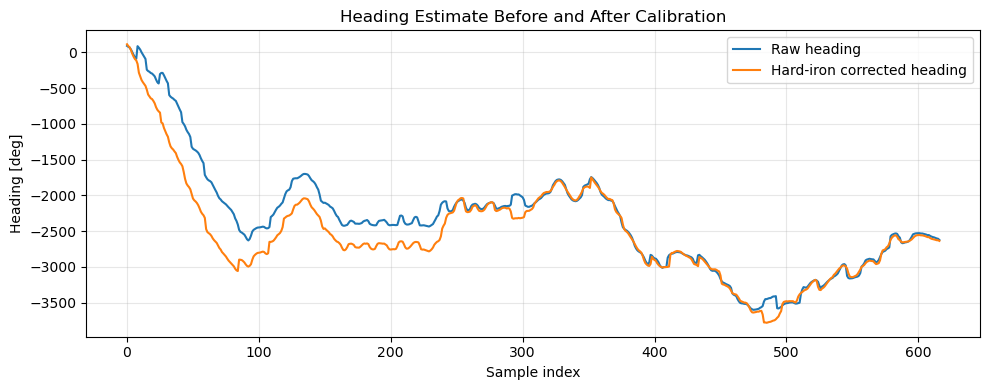

Raw heading range: 0.00° to 359.83°
Corrected heading range: 0.25° to 357.23°


In [47]:
# Heading estimate using horizontal magnetometer components
# atan2(My, Mx) gives heading in radians; convert to degrees in [0, 360)
heading_raw = (np.degrees(np.arctan2(np.array(my), np.array(mx))) + 360.0) % 360.0
heading_cal = (np.degrees(np.arctan2(np.array(my_cal), np.array(mx_cal))) + 360.0) % 360.0

# unwrap for smoother trend visualization
heading_raw_unwrap = np.degrees(np.unwrap(np.radians(heading_raw)))
heading_cal_unwrap = np.degrees(np.unwrap(np.radians(heading_cal)))

plt.figure(figsize=(10, 4))
plt.plot(t, heading_raw_unwrap, label='Raw heading')
plt.plot(t, heading_cal_unwrap, label='Hard-iron corrected heading')
plt.xlabel('Sample index')
plt.ylabel('Heading [deg]')
plt.title('Heading Estimate Before and After Calibration')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f'Raw heading range: {np.min(heading_raw):.2f}° to {np.max(heading_raw):.2f}°')
print(f'Corrected heading range: {np.min(heading_cal):.2f}° to {np.max(heading_cal):.2f}°')


### C.5 Writeup


Write down your hard iron offsets — you will need them in the firmware and the sensor fusion notebook.

| Axis | Offset (µT) |
|------|-------------|
| X    |   11.175    |
| Y    |   16.275    |
| Z    |  -15.825    |

**Discussion questions:**
1. Does your 3D scatter after calibration look like a sphere? If not, what shape is it and what might cause that?
    - After calibration, the 3D scatter plot looks like an elongated sphere. This is due to the offsets simply translating the sphere to the origin but does not account for scaling or distortion so each axis could be slightly more sensitive than others. As shown in the plot, the Magnitude range differs per axis further validating a soft-iron correction could be necessary. 
    
2. How complete is your coverage of orientations? Are there gaps in the scatter plot?
    - For recorded raw data, it can be seen in the XY and XZ plots that there is generally good coverage in each orientation. Looking closely at the XY plot, there's some blank areas slightly below the horizontal axis, and in the upper right corner. In the XZ plot, there's a horizontal gap from about Z=-20 to -30. 
    
3. What happens to your heading estimate if you skip calibration?
    - As seen in the raw data plots, the plotted points create a sphere whose center is not at the origin. This means that the heading is not pointing in the right direction. By skipping calibration, this error in the heading estimate would not be accounted for. By adjusting with the hard iron offsets, the data is calibrated such that the data is plotted with the center at the origin. 

Calibration Challenges:
- One challenge for the magnetometer calibration was ensuring that all orientations were sampled, as it was difficult to keep track of which directions were already accounted for. As seen in Question 2 and 3, a good calibration relies on having a good sample of the vector field to get proper offsets. 

# Module D: Pendulum

### D.1 Time-Series of Oscillating Axis

Chosen oscillating axis: AccY


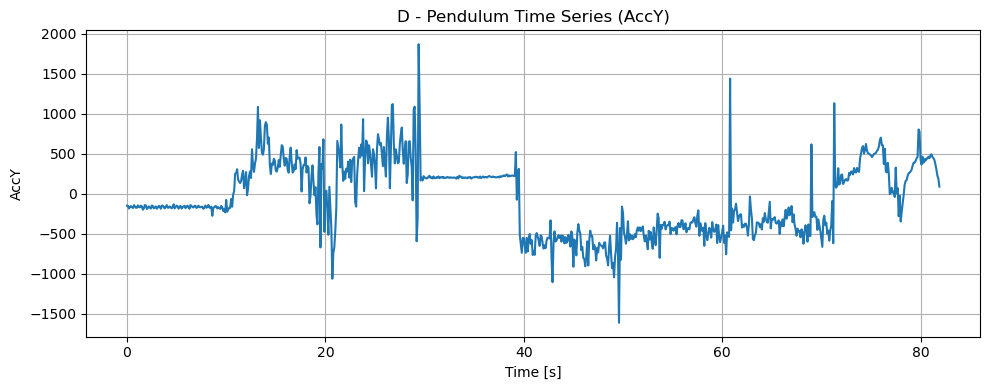

In [53]:
data_D = load_csv_dict("4_13_26\D.163degPendulum.csv")
n_D = len(next(iter(data_D.values())))
t_D = get_time_vector(data_D, n_D)
fs_D = sample_rate_from_t(t_D)
PENDULUM_LENGTH_M = 2.4638  
D_MIN_PEAK_DISTANCE_SEC = 0.5

# Gather available accelerometer and gyroscope channels
pendulum_series = {}
for name in ["AccX", "AccY", "AccZ", "GyrX", "GyrY", "GyrZ"]:
    if name in data_D:
        pendulum_series[name] = get_col(data_D, name)

# Pick the most oscillatory axis using standard deviation
best_name_D = None
best_signal_D = None
best_std_D = -np.inf
for name, sig in pendulum_series.items():
    s = np.nanstd(sig)
    if np.isfinite(s) and s > best_std_D:
        best_std_D = s
        best_name_D = name
        best_signal_D = sig

if best_signal_D is None:
    raise ValueError("No AccX/AccY/AccZ/GyrX/GyrY/GyrZ columns were found in the pendulum CSV.")

print(f"Chosen oscillating axis: {best_name_D}")

plt.figure(figsize=(10, 4))
plt.plot(t_D, best_signal_D)
plt.xlabel("Time [s]")
plt.ylabel(best_name_D)
plt.title(f"D - Pendulum Time Series ({best_name_D})")
plt.grid(True)
plt.tight_layout()
plt.show()


### D.2 Period Extraction and Comparison to $T = 2\pi\sqrt{L/g}$

Measured period from peaks [s]: 1.1667
Theoretical period [s]: 3.1494
Percent error [%]: -62.96


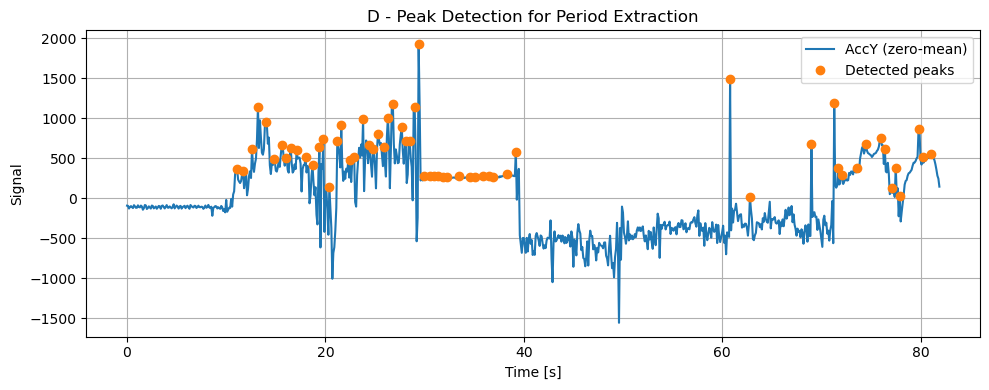

In [58]:

# Zero-mean signal for peak detection
y_D = best_signal_D - np.nanmean(best_signal_D)

# Simple local-max peak detection without scipy
candidate_peaks_D = []
for i in range(1, len(y_D) - 1):
    if np.isfinite(y_D[i-1]) and np.isfinite(y_D[i]) and np.isfinite(y_D[i+1]):
        if y_D[i] > y_D[i-1] and y_D[i] >= y_D[i+1] and y_D[i] > 0:
            candidate_peaks_D.append(i)

# Enforce minimum spacing between peaks
min_peak_distance_D = max(1, int(D_MIN_PEAK_DISTANCE_SEC * fs_D))
peaks_D = []
for idx in candidate_peaks_D:
    if not peaks_D or (idx - peaks_D[-1]) >= min_peak_distance_D:
        peaks_D.append(idx)
    elif y_D[idx] > y_D[peaks_D[-1]]:
        peaks_D[-1] = idx
peaks_D = np.array(peaks_D, dtype=int)

if len(peaks_D) >= 2:
    peak_times_D = t_D[peaks_D]
    periods_D = np.diff(peak_times_D)
    T_meas_D = float(np.nanmean(periods_D))
else:
    peak_times_D = np.array([])
    periods_D = np.array([])
    T_meas_D = np.nan

T_theory_D = 2 * np.pi * np.sqrt(PENDULUM_LENGTH_M / G)

print(f"Measured period from peaks [s]: {T_meas_D:.4f}")
print(f"Theoretical period [s]: {T_theory_D:.4f}")
if np.isfinite(T_meas_D):
    print(f"Percent error [%]: {100.0 * (T_meas_D - T_theory_D) / T_theory_D:.2f}")
else:
    print("Percent error [%]: could not compute because fewer than 2 peaks were detected.")

plt.figure(figsize=(10, 4))
plt.plot(t_D, y_D, label=f"{best_name_D} (zero-mean)")
if len(peaks_D) > 0:
    plt.plot(t_D[peaks_D], y_D[peaks_D], "o", label="Detected peaks")
plt.xlabel("Time [s]")
plt.ylabel("Signal")
plt.title("D - Peak Detection for Period Extraction")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


### D.3 PSD with Labeled Peak Frequency

Peak PSD frequency [Hz]: 0.0122
PSD-implied period [s]: 82.0000
Theoretical frequency [Hz]: 0.3175


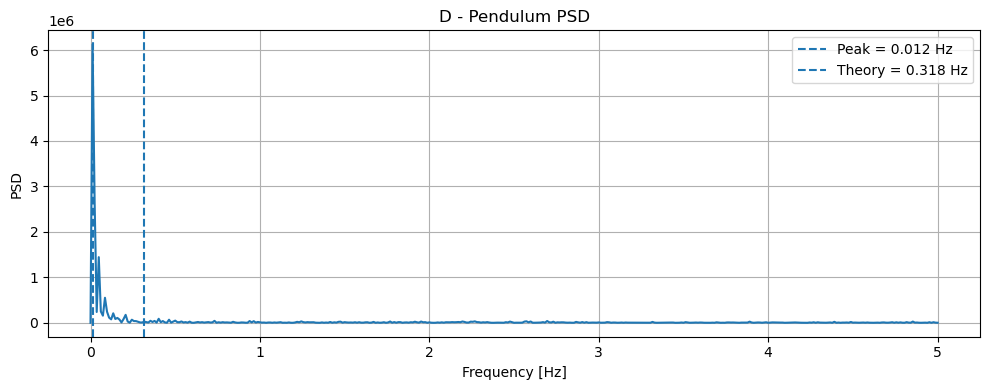

In [62]:

# PSD estimate using FFT (numpy only)
y_valid_D = y_D[np.isfinite(y_D)]
N_D = len(y_valid_D)
if N_D < 2:
    raise ValueError("Not enough valid pendulum samples for PSD.")

y_valid_D = y_valid_D - np.mean(y_valid_D)
freqs_D = np.fft.rfftfreq(N_D, d=1.0 / fs_D)
Y_D = np.fft.rfft(y_valid_D)
psd_D = (1.0 / (fs_D * N_D)) * np.abs(Y_D) ** 2
if len(psd_D) > 2:
    psd_D[1:-1] *= 2.0

# Ignore DC when finding the dominant oscillation peak
if len(freqs_D) > 1:
    peak_idx_D = 1 + np.argmax(psd_D[1:])
else:
    peak_idx_D = 0

f_peak_D = freqs_D[peak_idx_D]
T_psd_D = 1.0 / f_peak_D if f_peak_D > 0 else np.nan
f_theory_D = 1.0 / T_theory_D

print(f"Peak PSD frequency [Hz]: {f_peak_D:.4f}")
print(f"PSD-implied period [s]: {T_psd_D:.4f}")
print(f"Theoretical frequency [Hz]: {f_theory_D:.4f}")

plt.figure(figsize=(10, 4))
plt.plot(freqs_D, psd_D)
plt.axvline(f_peak_D, linestyle="--", label=f"Peak = {f_peak_D:.3f} Hz")
plt.axvline(f_theory_D, linestyle="--", label=f"Theory = {f_theory_D:.3f} Hz")
plt.xlabel("Frequency [Hz]")
plt.ylabel("PSD")
plt.title("D - Pendulum PSD")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# Extra Credit


### Explore the soft iron calibration for the magnetometer.

Since my plot from the Hard-iron Calibration is distorted, it demonstrates a need for soft iron calibration. Soft-Iron calibration corrects distortion for axis sensitivity and cross-axis coupling. 

Below, least square optimization was utilized as it minimizes the overall error in the non-linear model. It provides the an estimation based on noise assumptions and is efficient for this use-case as it balances accuracy and robustness by handling offsets and scaling effects. 

In [63]:
from scipy.optimize import least_squares
import numpy as np

data = np.column_stack([mx, my, mz])
def unpack_params(p):
    c = p[:3]
    # lower-triangular L
    l11, l21, l22, l31, l32, l33 = p[3:]
    L = np.array([
        [l11, 0.0, 0.0],
        [l21, l22, 0.0],
        [l31, l32, l33]
    ])
    return c, L

def residuals(p, X):
    c, L = unpack_params(p)
    Xc = X - c
    Y = (L @ Xc.T).T
    r = np.sqrt(np.sum(Y**2, axis=1))
    return r - 1.0

# Initial guess:
c0 = np.mean(data, axis=0)

# Use covariance to get a reasonable initial scaling
X0 = data - c0
cov0 = np.cov(X0, rowvar=False)
eigvals, eigvecs = np.linalg.eigh(cov0)
eigvals = np.maximum(eigvals, 1e-12)

# initial transform ~ inverse sqrt covariance
W0 = eigvecs @ np.diag(1.0 / np.sqrt(eigvals)) @ eigvecs.T

# convert W0 to lower-triangular form via Cholesky of W0.T @ W0
M0 = W0.T @ W0
L0 = np.linalg.cholesky(M0)

p0 = np.array([
    c0[0], c0[1], c0[2],
    L0[0, 0], L0[1, 0], L0[1, 1], L0[2, 0], L0[2, 1], L0[2, 2]
])

# Fit
result = least_squares(residuals, p0, args=(data,))
p_fit = result.x
center, L = unpack_params(p_fit)

# Apply calibration
data_centered = data - center
corrected = (L @ data_centered.T).T

r = np.linalg.norm(corrected, axis=1)
corrected = corrected / np.mean(r)

mx_fit = corrected[:, 0]
my_fit = corrected[:, 1]
mz_fit = corrected[:, 2]

print("Estimated hard-iron center:")
print(center)
print("\nEstimated soft-iron correction matrix L:")
print(L)

print("\nmeans:", np.mean(mx_fit), np.mean(my_fit), np.mean(mz_fit))
print("stds :", np.std(mx_fit), np.std(my_fit), np.std(mz_fit))
print("radius mean/min/max:", np.mean(np.linalg.norm(corrected, axis=1)),
      np.min(np.linalg.norm(corrected, axis=1)),
      np.max(np.linalg.norm(corrected, axis=1)))



Estimated hard-iron center:
[ 10.87375696  16.57413785 -15.55436006]

Estimated soft-iron correction matrix L:
[[ 0.02301542  0.          0.        ]
 [-0.00010772  0.02188851  0.        ]
 [ 0.00036611 -0.00069845  0.02270282]]

means: -0.018277621377139074 -0.10394760168330888 -0.022980098749925886
stds : 0.529912822865282 0.5800190661555314 0.6099873579782727
radius mean/min/max: 1.0 0.7778183545169742 1.1632429187009024


### Plot of the Soft-Iron Calibration based on Least-Square Approximation

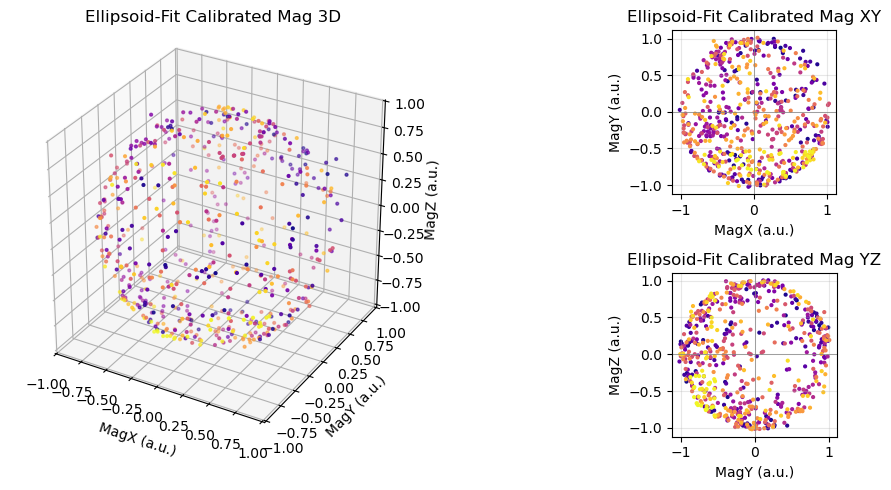

In [64]:

fig = plt.figure(figsize=(12, 5))
gs = GridSpec(2, 2, width_ratios=[1, 1.5])

# 3D
ax3d = fig.add_subplot(gs[:, 0], projection='3d')
ax3d.scatter(mx_fit, my_fit, mz_fit, s=4, c=t, cmap='plasma')
ax3d.set_title('Ellipsoid-Fit Calibrated Mag 3D')
ax3d.set_xlabel('MagX (a.u.)')
ax3d.set_ylabel('MagY (a.u.)')
ax3d.set_zlabel('MagZ (a.u.)')

xlim = [np.min(mx_fit), np.max(mx_fit)]
ylim = [np.min(my_fit), np.max(my_fit)]
zlim = [np.min(mz_fit), np.max(mz_fit)]

max_range = max(xlim[1]-xlim[0], ylim[1]-ylim[0], zlim[1]-zlim[0]) / 2
xmid = np.mean(xlim)
ymid = np.mean(ylim)
zmid = np.mean(zlim)

ax3d.set_xlim(xmid - max_range, xmid + max_range)
ax3d.set_ylim(ymid - max_range, ymid + max_range)
ax3d.set_zlim(zmid - max_range, zmid + max_range)
ax3d.set_box_aspect((1, 1, 1))

# XY
ax_xy = fig.add_subplot(gs[0, 1])
ax_xy.scatter(mx_fit, my_fit, s=4, c=t, cmap='plasma')
ax_xy.set_aspect('equal')
ax_xy.set_title('Ellipsoid-Fit Calibrated Mag XY')
ax_xy.set_xlabel('MagX (a.u.)')
ax_xy.set_ylabel('MagY (a.u.)')
ax_xy.axhline(0, color='gray', lw=0.5)
ax_xy.axvline(0, color='gray', lw=0.5)
ax_xy.grid(True, alpha=0.3)

# YZ
ax_yz = fig.add_subplot(gs[1, 1])
ax_yz.scatter(my_fit, mz_fit, s=4, c=t, cmap='plasma')
ax_yz.set_aspect('equal')
ax_yz.set_title('Ellipsoid-Fit Calibrated Mag YZ')
ax_yz.set_xlabel('MagY (a.u.)')
ax_yz.set_ylabel('MagZ (a.u.)')
ax_yz.axhline(0, color='gray', lw=0.5)
ax_yz.axvline(0, color='gray', lw=0.5)
ax_yz.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

As shown above, the least-square approximation scales the ellipse into a unit sphere. This addresses the scaling issue while implementing the translational changes due to the hard-iron calibration. AI helped me implement the least-square approximation and generate code that I was able to use with our collected data.